In [30]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

# Funzioni

In [31]:
def percento(vals, percento):
    f1, f2 = vals
    delta = abs(f1 - f2)
    incremento = delta * percento / 100
    return [f1 - incremento, f2 + incremento]

In [32]:
def chi_quadro(xdata,ydata,par,modello):
    somma = 0.
    vx, vsx = xdata
    vy, vsy = ydata
    for i,(x,y) in enumerate(zip(vx,vy)):
        y_star = modello(par,x)
        chi = ((y-y_star)/vsy[i])**2
        somma += chi
    return somma

In [33]:
def griglia_XY(x, sx, y, sy):
    risoluzione = 30
    zoom = 1    # fattore moltiplicativo
    x_range = np.linspace(x - zoom*sx, x + zoom*sx, risoluzione)
    y_range = np.linspace(y - zoom*sy, y + zoom*sy, risoluzione)
    return np.meshgrid(x_range, y_range)

In [34]:
def colonna_chi(X, Y, chi_quadri):
    colonna_X = []
    colonna_Y = []
    for i in range(X.shape[0]):
        colonna_Y.append(chi_quadri[i, :].min())
    for j in range(Y.shape[1]):
        colonna_X.append(chi_quadri[:, j].min())
    return np.array(colonna_X), np.array(colonna_Y)

In [35]:
# Funzioni interne di Chat
from matplotlib.ticker import FuncFormatter
import matplotlib.mathtext as mathtext

def latex_safe(s):
    try:
        test = rf"$\{s}$"
        mathtext.MathTextParser("agg").parse(test, dpi=100)
        return test
    except:
        return rf"${s}$"

def axis_formatter(values):
    max_val = max(abs(values.min()), abs(values.max()))
    if max_val == 0:
        scale = 1
    else:
        exp = int(np.floor(np.log10(max_val)))
        scale = 10**exp if abs(exp) > 2 else 1  # soglia notazione scientifica
    def formatter(x, pos):
        val = x / scale
        return f"{val:.4g}"  # max 4 cifre totali
    return formatter, scale

def label_con_unita(latex_label, unit, scale):
    base = rf"{latex_label} {unit}"
    if scale != 1:
        exp = int(np.log10(scale))
        return rf"{base} $\times 10^{{{exp}}}$"
    else:
        return base

In [36]:
def grafico_chi(x, sx, y, sy, chi_quadri, chi_columns, xlabel, ylabel, unitx, unity):

    # Creazione dei dati per il grafico
    X, Y = griglia_XY(x, sx, y, sy)

    # Creazione dei limiti del grafico
    chi2_min = chi_quadri.min()
    index = np.unravel_index(np.argmin(chi_quadri), chi_quadri.shape)
    x_min = X[index]
    y_min = Y[index]
    second_index = np.argmin(np.abs(chi_quadri - (chi2_min + 1)))
    second_index = np.unravel_index(second_index, chi_quadri.shape)
    chi_column_x, chi_column_y = chi_columns
    x_range = np.array([x - sx, x + sx])
    y_range = np.array([y - sy, y + sy])
    z_range = np.array([chi_quadri.min(), chi_quadri.max()])
    zoom = 50 # aumento percentuale
    xlim = percento(x_range, zoom)
    ylim = percento(y_range, zoom)
    zlim = percento(z_range, zoom)

    # Label sistemate per problemi con latex
    xlabel_latex = latex_safe(xlabel)
    ylabel_latex = latex_safe(ylabel)
    zlabel_latex = r"$\chi^2$"
    titolo = rf"$\chi^2 ( {xlabel_latex[1:-1]}, {ylabel_latex[1:-1]} )$"

    #############################
    ## GRAFICO 3D
    #############################
    # Creazione del grafico 3D
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1, projection='3d')
    ax.view_init(elev=20, azim=-60)
    ax.set(xlim=xlim, ylim=ylim, zlim=zlim)

    # Formattazione degli assi
    #gf.parametri_grafico(ax, titolo, xlabel=xlabel_latex, ylabel=ylabel_latex, zlabel=r"$\chi^2$", tridimensionale=True)
    fx, scalex = axis_formatter(x_range)
    fy, scaley = axis_formatter(y_range)
    fz, scalez = axis_formatter(z_range)
    ax.xaxis.set_major_formatter(FuncFormatter(fx))
    ax.yaxis.set_major_formatter(FuncFormatter(fy))
    ax.zaxis.set_major_formatter(FuncFormatter(fz))
    ax.set_xlabel(label_con_unita(xlabel_latex, unitx, scalex))
    ax.set_ylabel(label_con_unita(ylabel_latex, unity, scaley))
    ax.set_zlabel(label_con_unita(zlabel_latex, "", scalez))

    # Elementi del grafico
    ax.plot_surface(X, Y, chi_quadri, cmap='coolwarm', edgecolor='0.3', linewidth=0.1, alpha=0.6)
    ax.contourf(X, Y, chi_quadri, zdir='x', offset=xlim[0], cmap='coolwarm', alpha=1)
    ax.contourf(X, Y, chi_quadri, zdir='y', offset=ylim[1], cmap='coolwarm', alpha=1)
    ax.contourf(X, Y, chi_quadri, zdir='z', offset=zlim[0], cmap='coolwarm', alpha=1)
    ax.plot(X[0,:], chi_column_x, zs=ylim[1], zdir='y', color='black', linewidth=2)
    ax.plot(Y[:,0], chi_column_y, zs=xlim[0], zdir='x', color='black', linewidth=2)
    #cs = ax.contour(X, Y, chi_quadri, levels=10, colors='k', linewidths=0.5)
    #ax.clabel(cs, inline=True, fontsize=9, fmt='%.0f')

    # Salvataggio del grafico
    gf.salva_grafico(fig, f"Chi/{xlabel}_{ylabel}.pdf", tridimensionale=True)

    #############################
    ## GRAFICO 2D
    #############################
    fig, ax = plt.subplots(2, 2, height_ratios=[3, 1], width_ratios=[1,3], constrained_layout = True, sharex='col', sharey='row')
    [[ax2, ax1], [ax4, ax3]] = ax

    # Formattazione degli assi
    ax4.axis('off')
    ax1.set_title(titolo)
    ax1.tick_params(labelbottom=False,bottom=False)
    ax2.tick_params(labelleft=False,left=False,bottom=False)
    ax3.tick_params(labelbottom=False,bottom=False,left=False)

    ax1 = fig.add_subplot(2,2,2)
    ax1.text(x_min, y_min, f"{chi2_min:.2f}", fontsize=10, ha='left', va='bottom')
    ax1.axhline(y_min, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax1.axvline(x_min, color='black', linestyle='--', linewidth=1, alpha=0.3)
    colore = ax1.pcolormesh(X, Y, chi_quadri, shading='auto', cmap='coolwarm')
    fig.colorbar(colore, ax=ax1, label=r"$\chi^2$")

    ax2 = fig.add_subplot(2,2,1)
    ax2.set_ylabel(ylabel_latex + unity)
    #ax2.set_xticks([int(chi2_min),int(chi2_min+2),int(chi2_min+4),int(chi2_min+6)])
    ax2.axhline(y_min, color='black', linestyle='--', linewidth=1, alpha=0.3)
    #ax2.axhline(Y[second_index], color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax2.text(chi2_min + (zlim[1] - zlim[0]) * 0.07, y_min, f"{y_min:.5e}", fontsize=10, ha='left', va='bottom')
    ax2.plot(chi_column_y, Y[:,0], color='black', linewidth=2)

    ax3 = fig.add_subplot(2,2,4)
    ax3.set_xlabel(xlabel_latex + unitx)
    #ax3.set_yticks([int(chi2_min),int(chi2_min+2),int(chi2_min+4),int(chi2_min+6)])
    ax3.axvline(x_min, color='black', linestyle='--', linewidth=1, alpha=0.3)
    #ax3.axvline(X[second_index], color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax3.text(x_min, chi2_min + (zlim[1] - zlim[0]) * 0.07, f"{x_min:.5e}", fontsize=10, ha='center', va='bottom')
    ax3.plot(X[0,:], chi_column_x, color='black', linewidth=2)
    gf.salva_grafico(fig, f"Chi/{xlabel}_{ylabel}_proiezione.pdf", tridimensionale=True)

# Lettura Dati

In [37]:
anal,xdata,ydata = gf.importa_pickle("analisi.pkl")

def modello(par, x):
    a,b,d = par
    return a/b * np.exp(- ( x ) / d ) * ( 1/d * np.sin(b * ( x ) ) + b * np.cos(b * ( x ) ) )

Creazione array per v, omega e tau

In [38]:
[[v0, s_v], [omega0, s_omega], [tau0, s_tau]] = anal

# Grafici

## 1. Omega e Tau

Creazione griglia chi

In [39]:
O, T = griglia_XY(omega0, s_omega, tau0, s_tau)

chi_quadri = np.zeros_like(O)
for i in range(O.shape[0]):
    for j in range(O.shape[1]):
        parametri = [anal[0][0], O[i, j], T[i, j]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

chi_column = colonna_chi(O, T, chi_quadri)

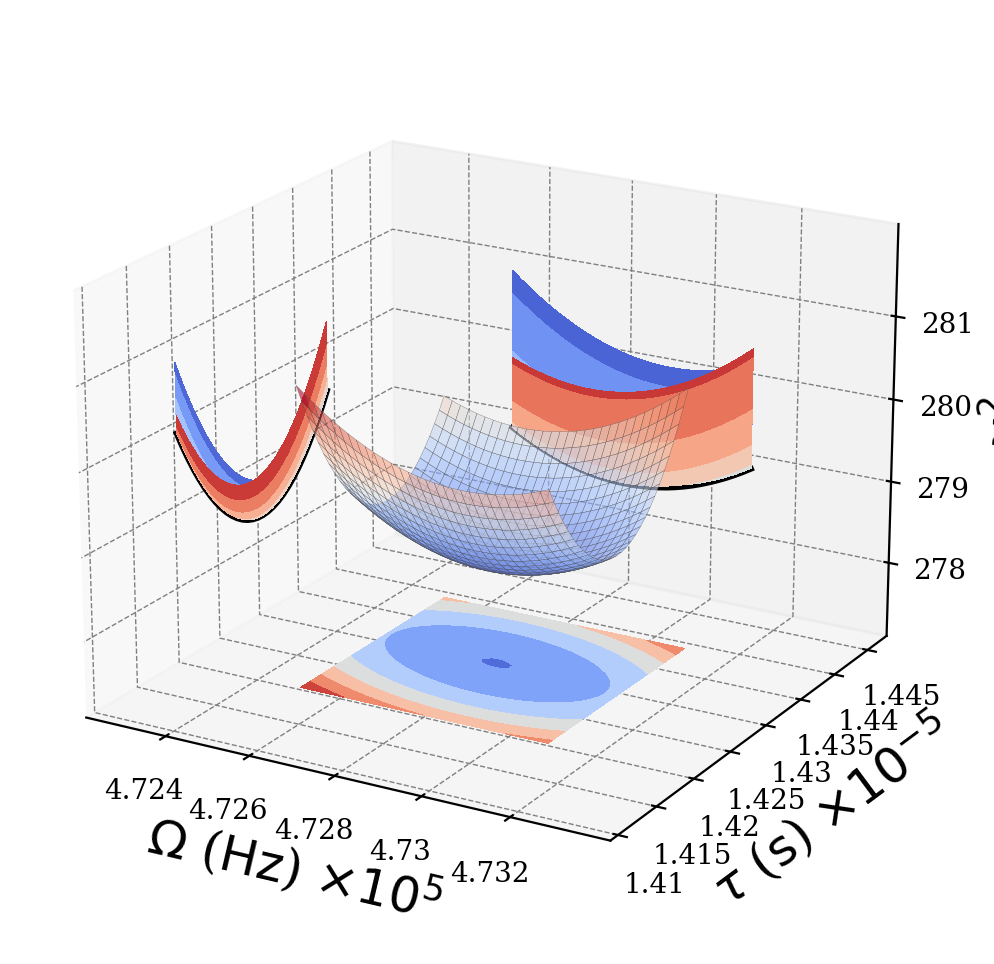

/tmp/ipykernel_44912/3205249389.py:79: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  colore = ax1.pcolormesh(X, Y, chi_quadri, shading='auto', cmap='coolwarm')


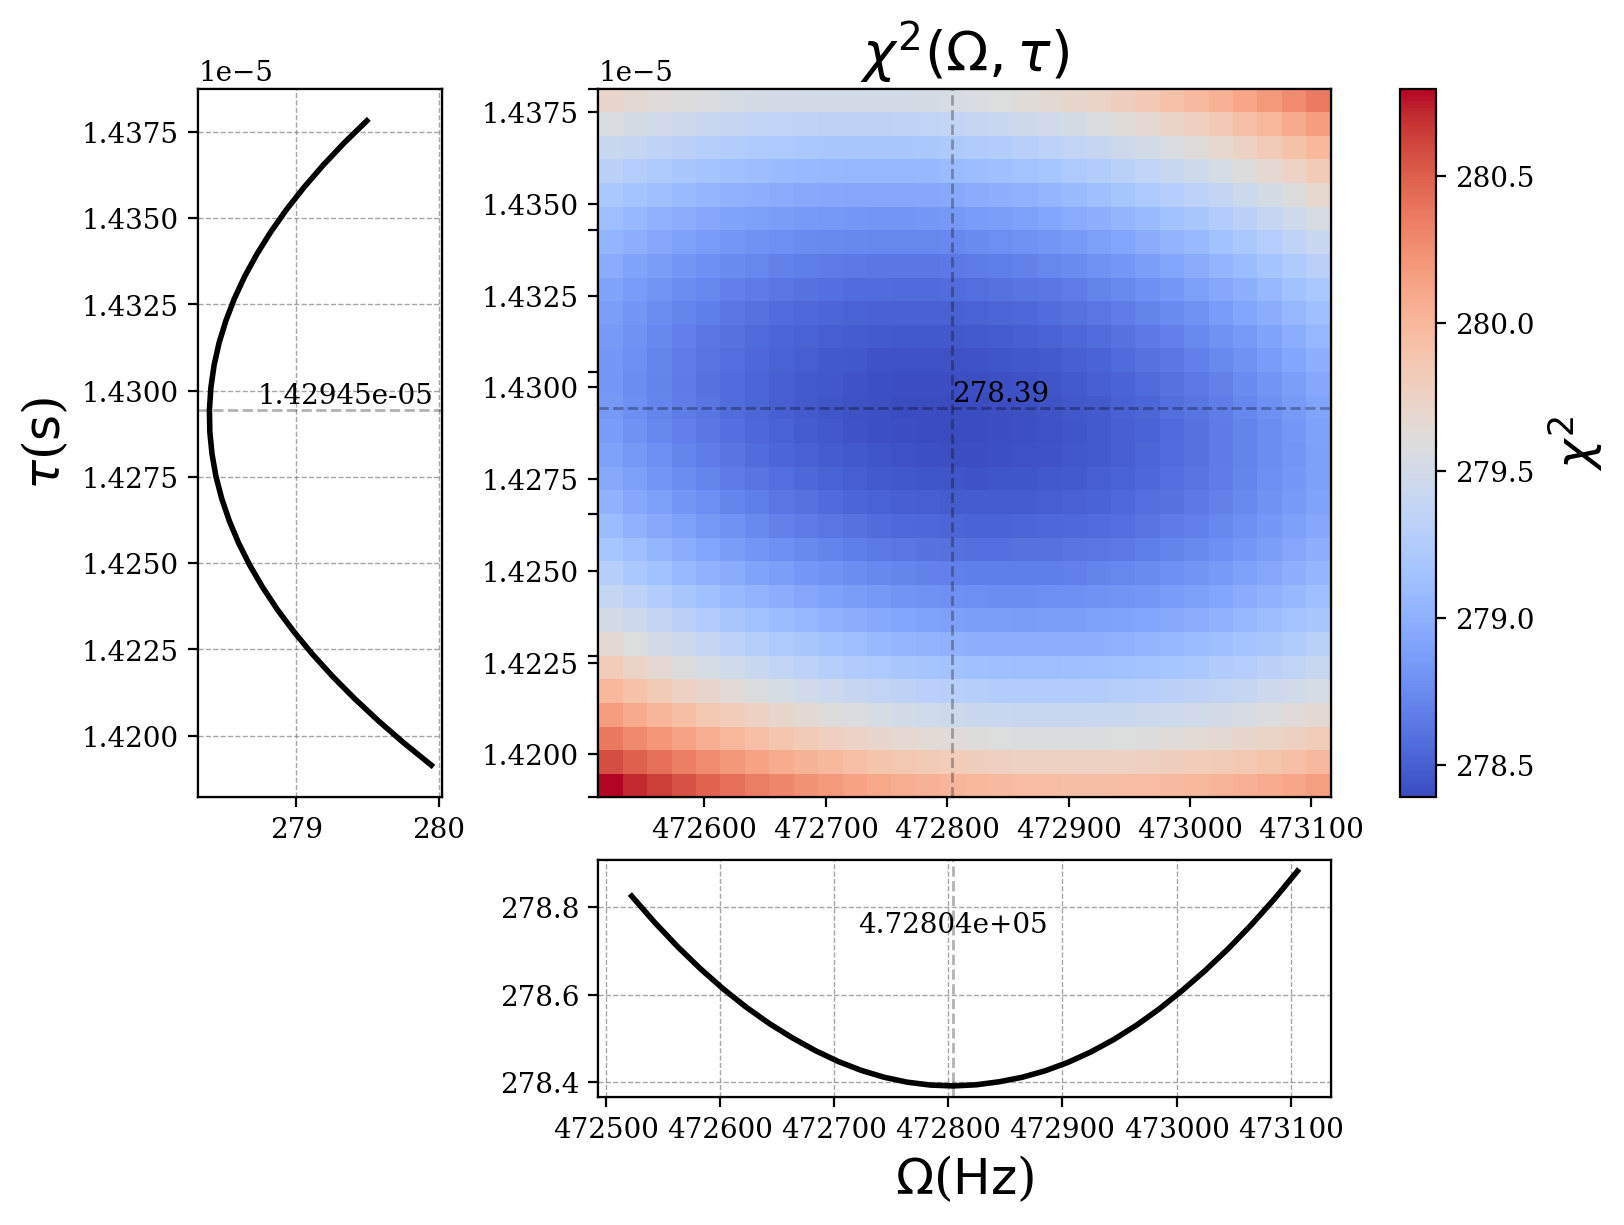

In [40]:
grafico_chi(omega0, s_omega, tau0, s_tau, chi_quadri, chi_column, "Omega", "tau", r"($\mathrm{Hz}$)", r"($\mathrm{s}$)")

## 2. V e Tau

Creazione griglia chi

In [41]:
V, T = griglia_XY(v0, s_v, tau0, s_tau)

chi_quadri = np.zeros_like(V)
for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        parametri = [V[i, j], anal[1][0], T[i, j]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

chi_column = colonna_chi(V, T, chi_quadri)

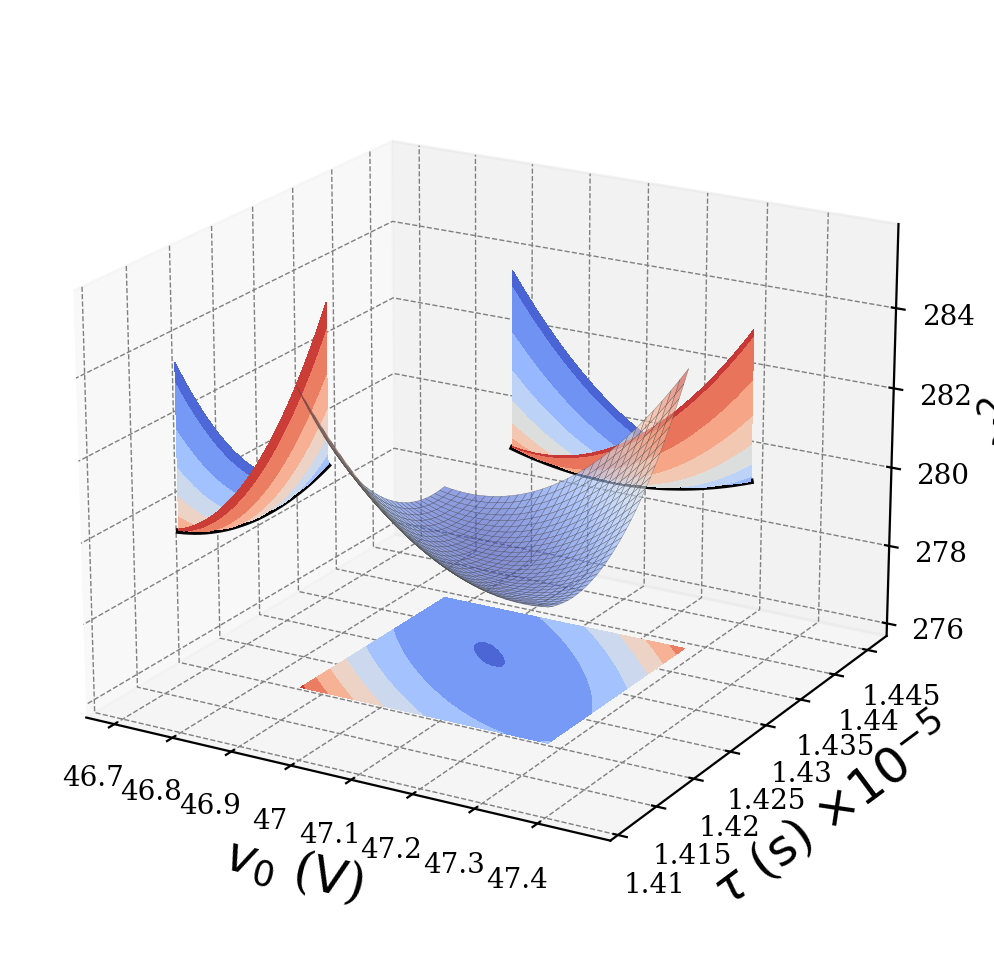

/tmp/ipykernel_44912/3205249389.py:79: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  colore = ax1.pcolormesh(X, Y, chi_quadri, shading='auto', cmap='coolwarm')


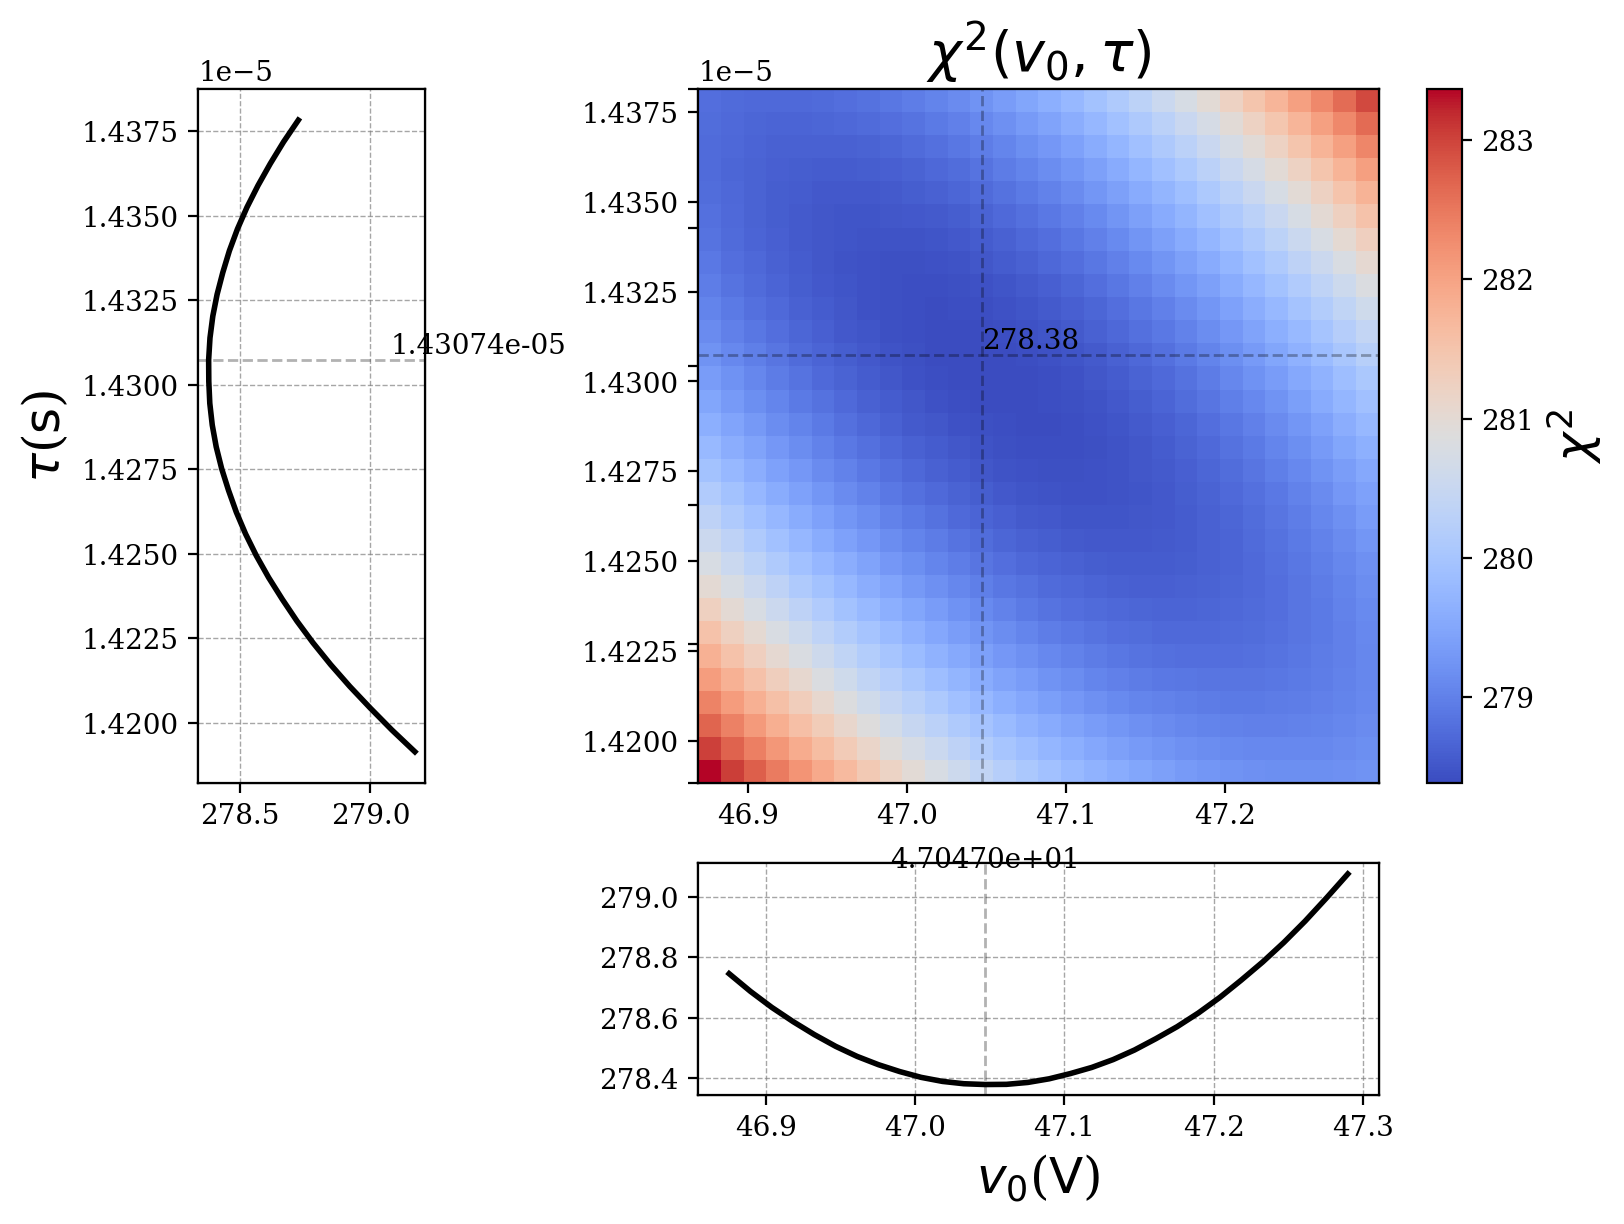

In [42]:
grafico_chi(v0, s_v, tau0, s_tau, chi_quadri, chi_column, "v_0", "tau", r"($\mathrm{V}$)", r"($\mathrm{s}$)")